# Fit the narrow lines of SDSS J102530.29+140207.4
* Remove the stellar component
* Determine the refined redshift
* Create the narrow line template

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy

from astropy.modeling import models, fitting
import sys
sys.path.append('/Users/shangguan/Softwares/my_modules/SAGAN/')
import galspec
from extinction import ccm89, remove
import spectres

import temp_utils as tu

import matplotlib as mpl
mpl.rc("xtick", direction="in", labelsize=16)
mpl.rc("ytick", direction="in", labelsize=16)
mpl.rc("xtick.major", width=1., size=8)
mpl.rc("ytick.major", width=1., size=8)
mpl.rc("xtick.minor", width=1., size=5)
mpl.rc("ytick.minor", width=1., size=5)

# automatic reload the modules
%load_ext autoreload
%autoreload 2

ls_km = 2.99792e5 # km/s
wave_dict = galspec.utils.line_wave_dict
label_dict = galspec.utils.line_label_dict

label_bHa = tu.line_label_map['bHalpha']
label_bHb = tu.line_label_map['bHbeta']
label_bHg = tu.line_label_map['bHgamma']
label_aHa = tu.line_label_map['aHalpha']
label_aHb = tu.line_label_map['aHbeta']
label_aHg = tu.line_label_map['aHgamma']
label_bHeII = tu.line_label_map['bHeII']
label_bHeI = tu.line_label_map['bHeI']

resolving_power = 1800

/Users/shangguan/Softwares/miniforge3/envs/norm/lib/python3.13/site-packages/spectres/spectral_resampling.py:104: RuntimeWarning: Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument (by default 0).
  warnings.warn(


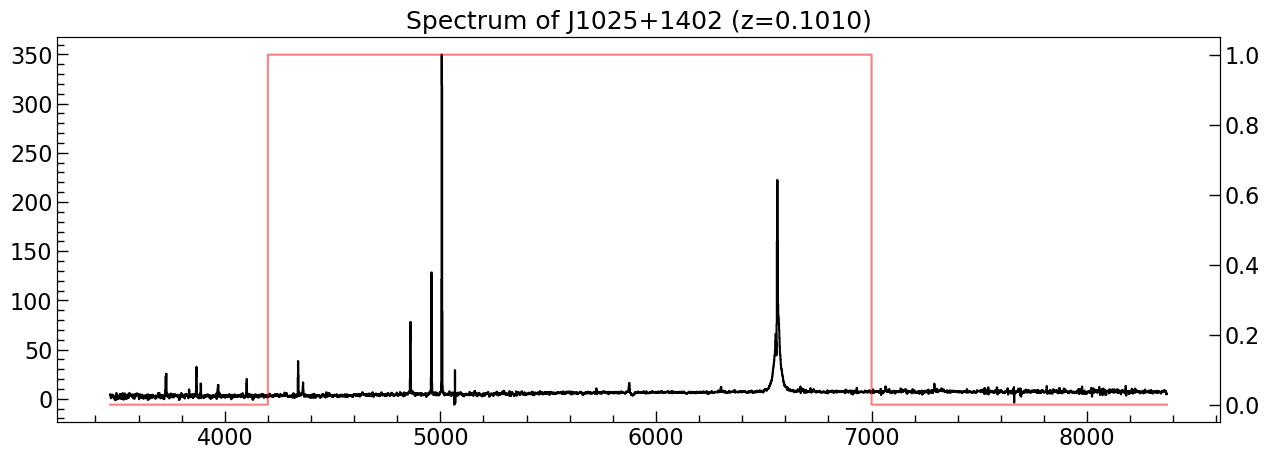

In [2]:
# get spectrum
tb = Table.read('../data_20251121/target_info.ipac', format='ipac')
loop = 1
targname = tb['Name'][loop]
Av = tb['Av'][loop]
zred = tb['zred'][loop]

# Read data
spec = np.loadtxt('results/J1025+1402_nostar.txt')
wave_use = spec[:, 0] / (1 + zred)
flux_use = spec[:, 1]
ferr_use = spec[:, 2]

# Read the templates
temp_oiii = np.loadtxt('results/J1025+1402_oiii.txt')
velc_temp = temp_oiii[:, 0]
flux_temp = temp_oiii[:, 1]

wave_uni = np.linspace(wave_use.min(), wave_use.max(), len(wave_use))
flux_use, ferr_use = spectres.spectres(wave_uni, wave_use, flux_use, ferr_use)
fltr = ~np.isnan(flux_use) & ~np.isnan(ferr_use)
flux_use = flux_use[fltr]
ferr_use = ferr_use[fltr]
wave_use = wave_uni[fltr]


# include the H-alpha, H-beta, and H-gamma line regions
weight_lines = np.zeros_like(wave_use)
line_windows = [(4200, 5400), (5400, 6100), (6100, 7000)]
#line_windows = [(4200, 4500), (4750, 5100), (6400, 6800)]
for window in line_windows:
    weight_lines[(wave_use > window[0]) & (wave_use < window[1])] = 1

fig, ax = plt.subplots(figsize=(15, 5))
ax.step(wave_use, flux_use, color='k', where='mid', label='Flux')
ax.minorticks_on()

#ax.axvline(6363.776, color='C3', ls='--', alpha=0.7)
#ax.axvline(6300.304, color='C3', ls='--', alpha=0.7)
#ax.set_xlim([6200, 7000])
#ax.set_ylim([0, 38])


axr = ax.twinx()
axr.step(wave_use, weight_lines, color='r', where='mid', alpha=0.5, label='Line Regions')
ax.set_title(f'Spectrum of {targname} (z={zred:.4f})', fontsize=18)
plt.show()

## Fit the lines
* Fix the absorption line width to 70 km/s as it is not resolved.

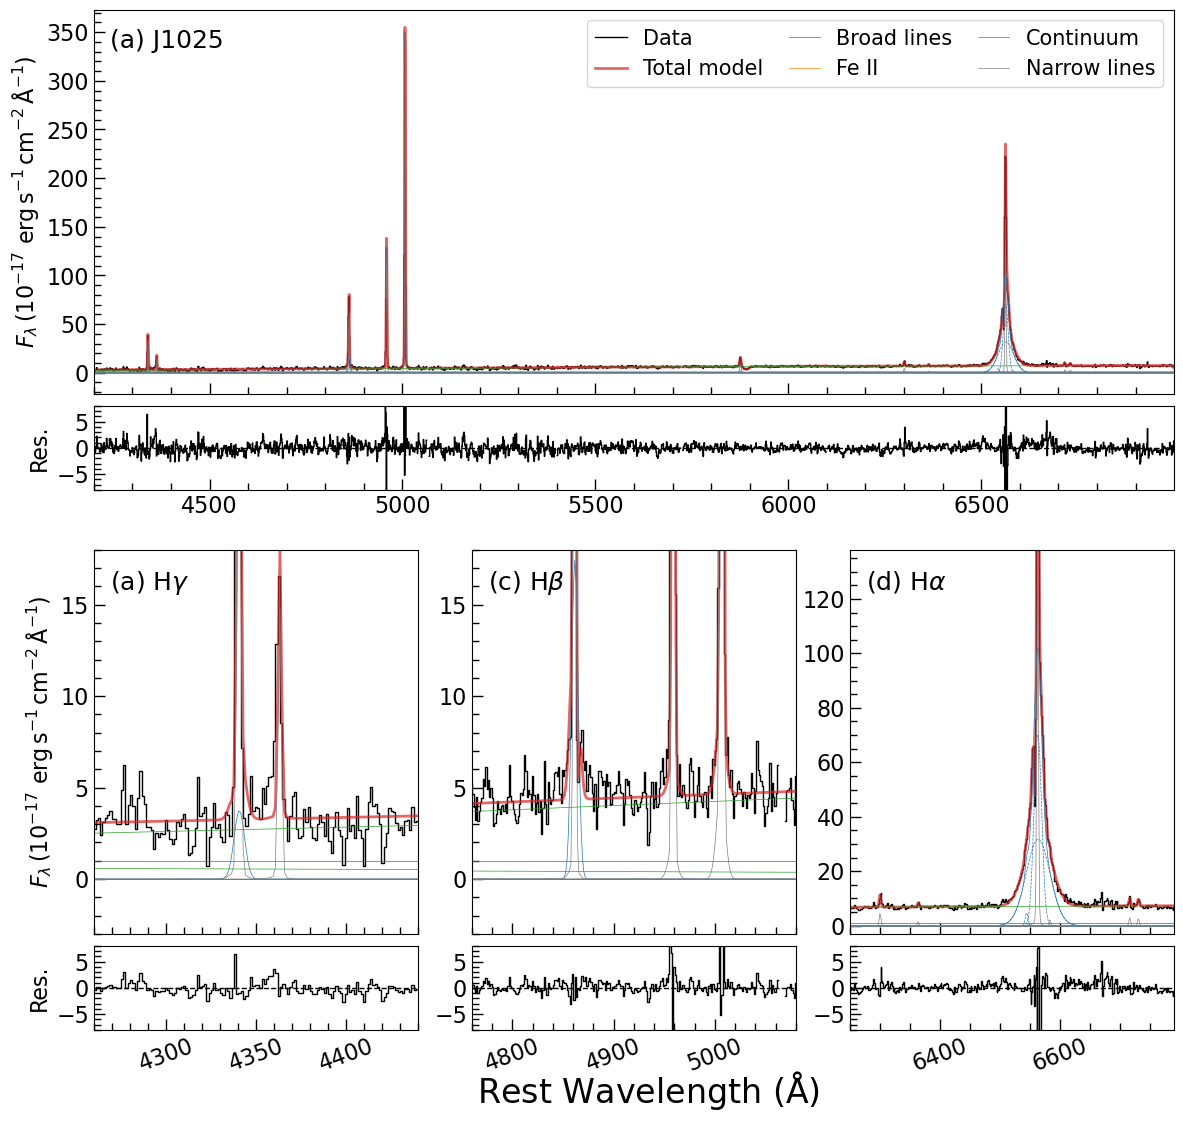

<Line_MultiGauss(amp_c=17.43674097, dv_c=26.67454369, sigma_c=200., wavec=4861.333, name='Broad H$\\beta$')>
<Line_MultiGauss(amp_c=3.77113729, dv_c=26.67454369, sigma_c=200., wavec=4340.471, name='Broad H$\\gamma$')>
<WindowedPowerLaw1D(amplitude=0.36787014, x_0=5100., alpha=2.48962469, x_min=4200., x_max=5400., name='PL')>
<BlackBody(temperature=3766.00508827, scale=7.19407202, x_min=4200., x_max=5400., name='BB')>
<Line_Absorption(logtau0=0.34464844, dv=-169.58399469, sigma=21.00262143, Cf=1., wavec=4861.333, name='Abs. H$\\beta$')>
<Line_Absorption(logtau0=-0.12818798, dv=-169.58399469, sigma=21.00262143, Cf=1., wavec=4340.471, name='Abs. H$\\gamma$')>
<Line_Absorption(logtau0=2., dv=202.32124928, sigma=30., Cf=0.8, wavec=4861.333, name='Abs. H$\\beta$2')>
<IronTemplate(amplitude=0., stddev=596.35048516, z=-0.003, name='Fe II')>
<Line_template(amplitude=63.21062166, dv=8.94729656, wavec=4861.333, name='nHbeta')>
<Line_template(amplitude=33.81795807, dv=8.94729656, wavec=4340.471, n

In [ ]:
#################################################################################
# Fit Halpha + Hbeta + Hgamma
weight_lines = np.zeros_like(wave_use)
xlim = [wave_use.max(), wave_use.min()]
for window in line_windows:
    weight_lines[(wave_use > window[0]) & (wave_use < window[1])] = 1
    xlim[0] = min(xlim[0], window[0])
    xlim[1] = max(xlim[1], window[1])
weight_lines[(wave_use > 5398) & (wave_use < 5403)] = 0
weight_lines[(wave_use > 6097) & (wave_use < 6103)] = 0

for w0, w1 in tu.spec_masks['J1025']:
    weight_lines[(wave_use > w0) & (wave_use < w1)] = 0  # Mask some back pixels


# Halpha
cont_ha = galspec.WindowedPowerLaw1D(amplitude=7.02018858, x_0=6550., alpha=-0.93248672, 
                                   x_min=line_windows[2][0], x_max=line_windows[2][1], name='Cont Ha')

bha = galspec.Line_MultiGauss(n_components=3, amp_c=70.13652265, dv_c=44.39212731, sigma_c=339.65874487, 
                            amp_w0=0.34039491, dv_w0=1.64542289, sigma_w0=1018.41837694, 
                            amp_w1=0.08452459, dv_w1=-854.57908612, sigma_w1=146.72568159,
                            wavec=wave_dict['Halpha'], name=label_bHa)
bha.dv_w1.fixed = True
nha = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=148.10647995, dv=8.57651541,
                          wavec=wave_dict['Halpha'], name='nHalpha')
ns2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2.65797224, dv=8.57651541,
                          wavec=wave_dict['SII_6716'], name='SII_6716') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2.57408749, dv=8.57651541,
                         wavec=wave_dict['SII_6731'], name='SII_6731')
nn2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=3.97457771, dv=8.57651541, 
                          wavec=wave_dict['NII_6583'], name='NII_6583') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=1.34276274, dv=8.57651541, 
                         wavec=wave_dict['NII_6548'], name='NII_6548')
no1 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=4.32654165, dv=8.57651541,
                          wavec=wave_dict['OI_6300'], name='OI_6300') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=1.44218055, dv=8.57651541,
                          wavec=wave_dict['OI_6364'], name='OI_6364')

aha = galspec.Line_Absorption(logtau0=0.71635899, dv=-160.79887661, sigma=22.08505311, Cf=0.99017218, 
                            wavec=wave_dict['Halpha'], name=label_aHa)
aha.sigma.bounds = (5, 300)

b_lines = (bha + cont_ha) * aha
b_lines = galspec.convolve_lsf(b_lines, wavec=bha.wavec, resolving_power=resolving_power)
n_lines = nha + ns2 + nn2 + no1
m_fit_ha = b_lines + n_lines
m_fit_ha['NII_6548'].amplitude.tied = galspec.tie_template_amplitude('NII_6583', ratio=2.96)
m_fit_ha['OI_6364'].amplitude.tied = galspec.tie_template_amplitude('OI_6300', ratio=3.0)

for ln in ['SII_6716', 'SII_6731', 'NII_6583', 'NII_6548', 'OI_6300', 'OI_6364']:  #
    m_fit_ha[ln].dv.tied = galspec.tie_template_dv('nHalpha')

#################################################################################
# He I 5876
cont_he1 = galspec.WindowedPowerLaw1D(amplitude=6.12946892, x_0=5750., alpha=-1.59101302, 
                                   x_min=line_windows[1][0], x_max=line_windows[1][1], name=f"Cont HeI")
bhe1 = galspec.Line_MultiGauss(n_components=1, amp_c=7.51229832, dv_c=18.93079722, sigma_c=107.87926235, 
                             wavec=wave_dict['HeI_5876'], name=label_bHeI)
nhe1 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2.11753264, dv=8.94731778, 
                           wavec=wave_dict['HeI_5876'], name='nHeI_5876')
aNaD = galspec.Line_Absorption_doublet(logtau0=0.28340269, logtau1=-0.7537409, dv=-36.65681093, sigma=239.4581233, Cf=0.47168378, 
                                     wavec0=wave_dict['NaD_5890'], wavec1=wave_dict['NaD_5896'], name='Na D')
m_fit_he1 = cont_he1 * aNaD + bhe1 + nhe1

#################################################################################
# Hbeta
pl = galspec.WindowedPowerLaw1D(amplitude=0.25717318, x_0=5100., alpha=2.48962469, x_min=line_windows[0][0], x_max=line_windows[0][1],
                              fixed={'x_0': True, 'alpha': True}, name='PL')  #  Cannot free this...
bb = galspec.BlackBody(temperature=3800.53987992, scale=7.19407202, x_min=line_windows[0][0], x_max=line_windows[0][1],
                     fixed={'scale': True}, name='BB')  #
cont = pl + bb
iron = galspec.IronTemplate(amplitude=0.00119117, stddev=428.64784118, z=-0.00004983, name='Fe II')  #, fixed=dict(amplitude=True, z=True, stddev=True)

bhb = galspec.Line_MultiGauss(n_components=1, amp_c=7.96092411, dv_c=44.39212731, sigma_c=305.0241163,
                            wavec=wave_dict['Hbeta'], name=label_bHb)
bhb.sigma_c.bounds = (200, 1000)
nhb = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=73.54572642, dv=8.57651541, 
                          wavec=wave_dict['Hbeta'], name='nHbeta')
no3 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=415.07625723, dv=8.57651541, 
                          wavec=wave_dict['OIII_5007'], name='OIII_5007') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=139.28733464, dv=8.57651541, 
                         wavec=wave_dict['OIII_4959'], name='OIII_4959')
#no3_w = galspec.Line_MultiGauss_doublet(n_components=1, amp_c0=5, amp_c1=1.3, dv_c=-140, sigma_c=280, 
#                                      wavec0=wave_dict['OIII_5007'], wavec1=wave_dict['OIII_4959'], name='[OIII]w')
ahb = galspec.Line_Absorption(logtau0=-0.13673054, dv=-160.79887661, sigma=22.08505311, Cf=0.99017218, 
                            wavec=wave_dict['Hbeta'], name=label_aHb)
ahb.sigma.bounds = (5, 300)
ahb2 = galspec.Line_Absorption(logtau0=1.140562, dv=242.8452392, sigma=30., Cf=0.8, wavec=wave_dict['Hbeta'], name=label_aHb+'2')
ahb2.Cf.fixed = True
ahb2.sigma.fixed = True
ahb2.sigma.bounds = (5, 300)

# Hgamma
bhg = galspec.Line_MultiGauss(n_components=1, amp_c=0.5, dv_c=47.43140249, sigma_c=637.5607882,
                            #amp_w0=0.14521271, dv_w0=-20.76443383, sigma_w0=1428.23875816, 
                            #amp_w1=0.14233795, dv_w1=956.81234491, sigma_w1=262.7280666,
                            wavec=wave_dict['Hgamma'], name=label_bHg)
nhg = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=36.05525959, dv=8.57651541, 
                          wavec=wave_dict['Hgamma'], name='nHgamma')
no3_4363 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=15.59414757, dv=8.57651541, 
                               wavec=wave_dict['OIII_4363'], name='OIII_4363')
#no3_4363_w = galspec.Line_MultiGauss(n_components=2, amp_c=5, dv_c=-102.72494161, sigma_c=138.17275064, 
#                                   amp_w0=0.51564118, dv_w0=-57.20856779, sigma_w0=300.65959177,
#                                   wavec=wave_dict['OIII_4363'], name='OIII_4363_w')
ahg = galspec.Line_Absorption(logtau0=-0.60956697, dv=-160.79887661, sigma=22.08505311, Cf=0.99017218, 
                            wavec=wave_dict['Hgamma'], name=label_aHg)
ahg.sigma.bounds = (5, 300)


#m_init = (bhb + cont_hb + nhb) * ahb * ahb2 + no3 + deepcopy(m_fit_ha)
b_lines = (bhb + bhg + cont) * ahb * ahg * ahb2  #
b_lines = galspec.convolve_lsf(b_lines, wavec=bhb.wavec, resolving_power=resolving_power)
m_init = b_lines + iron + nhb + nhg + no3 + no3_4363 + m_fit_ha + m_fit_he1

for ln in ['nHbeta', 'OIII_5007', 'OIII_4959', 'nHgamma', 'OIII_4363', 'nHeI_5876']:
    m_init[ln].dv.tied = galspec.tie_template_dv('nHalpha')

m_init['OIII_4959'].amplitude.tied = galspec.tie_template_amplitude('OIII_5007', 2.98)

m_init[label_aHb].logtau0.tied = galspec.tie_Absorption_logtau0(label_aHa, ratio=7.13)
m_init[label_aHg].logtau0.tied = galspec.tie_Absorption_logtau0(label_aHa, ratio=21.18)
m_init[label_aHb].dv.tied = galspec.tie_Absorption_dv(label_aHa)
m_init[label_aHg].dv.tied = galspec.tie_Absorption_dv(label_aHa)
m_init[label_aHb].Cf.tied = galspec.tie_Absorption_Cf(label_aHa)
m_init[label_aHg].Cf.tied = galspec.tie_Absorption_Cf(label_aHa)
m_init[label_aHb].sigma.tied = galspec.tie_Absorption_sigma(label_aHa)
m_init[label_aHg].sigma.tied = galspec.tie_Absorption_sigma(label_aHa)

m_init[label_bHb].dv_c.tied = galspec.tie_MultiGauss_dv_c(label_bHa)
m_init[label_bHg].dv_c.tied = galspec.tie_MultiGauss_dv_c(label_bHa)
m_init[label_bHg].sigma_c.tied = galspec.tie_MultiGauss_sigma_c(label_bHb)  # Since Hgamma is not detected; I tie it to Hbeta

fwhm_ha = galspec.line_emission_fwhm(m_init, [label_bHa], wave_use, wave_dict['Halpha'])
m_init['Fe II'].amplitude.bounds = (0, None)
m_init['Fe II'].stddev = fwhm_ha/2.3548
m_init['Fe II'].stddev.bounds = (fwhm_ha/2.3548/1.5, fwhm_ha/2.3548*1.5)
m_init['Fe II'].z.bounds = (-0.003, 0.003)


fitter = fitting.LevMarLSQFitter()
m_fit_hb = fitter(m_init, wave_use, flux_use, weights=weight_lines, maxiter=10000)

tu.plot_all_4p_J1025(wave_use, flux_use, m_fit_hb, weight=weight_lines)
#plt.savefig('results/figs/J1025+1402_4p_levmar.pdf', bbox_inches='tight')
plt.show()

for m in m_fit_hb:
    print(m.__repr__())

In [6]:
##################################################################################
print('Running MCMC with all parameters varying...')
mcmc = tu.run_mcmc_all(m_init, wave_use, flux_use, ferr_use, weight_lines, 
                       nwalkers=200, nsteps=100, nburn=50, fit=False)
mcmc.fit()

Running MCMC with all parameters varying...
MCMC_Fit initialized with 45 free parameters.


100%|██████████| 100/100 [00:18<00:00,  5.31it/s]


(array([[  7.94794253, 305.0667974 ,   0.51077828, ...,  18.97681793,
         107.89020885,   2.12776326],
        [  7.92609817, 305.01008049,   0.45666706, ...,  18.95082924,
         107.89916135,   2.08866949],
        [  7.95369915, 305.03557423,   0.49189   , ...,  18.89842389,
         107.91036659,   2.12378273],
        ...,
        [  7.93692201, 305.0169198 ,   0.52203903, ...,  18.91643787,
         107.9674026 ,   2.12913557],
        [  7.95222662, 305.02383353,   0.49047983, ...,  18.91168225,
         107.88186381,   2.11609686],
        [  7.9546627 , 305.01661516,   0.5034299 , ...,  18.9277032 ,
         107.87396706,   2.1187521 ]]),
 <CompoundModel(amp_c_0=7.95222662, dv_c_0=44.36989051, sigma_c_0=305.02383353, wavec_0=4861.333, amp_c_1=0.49047983, dv_c_1=44.36989051, sigma_c_1=305.02383353, wavec_1=4340.471, amplitude_2=0.24062194, x_0_2=5100., alpha_2=2.48962469, x_min_2=4200., x_max_2=5400., temperature_3=3800.557665, scale_3=7.19407202, x_min_3=4200., x_max_3=

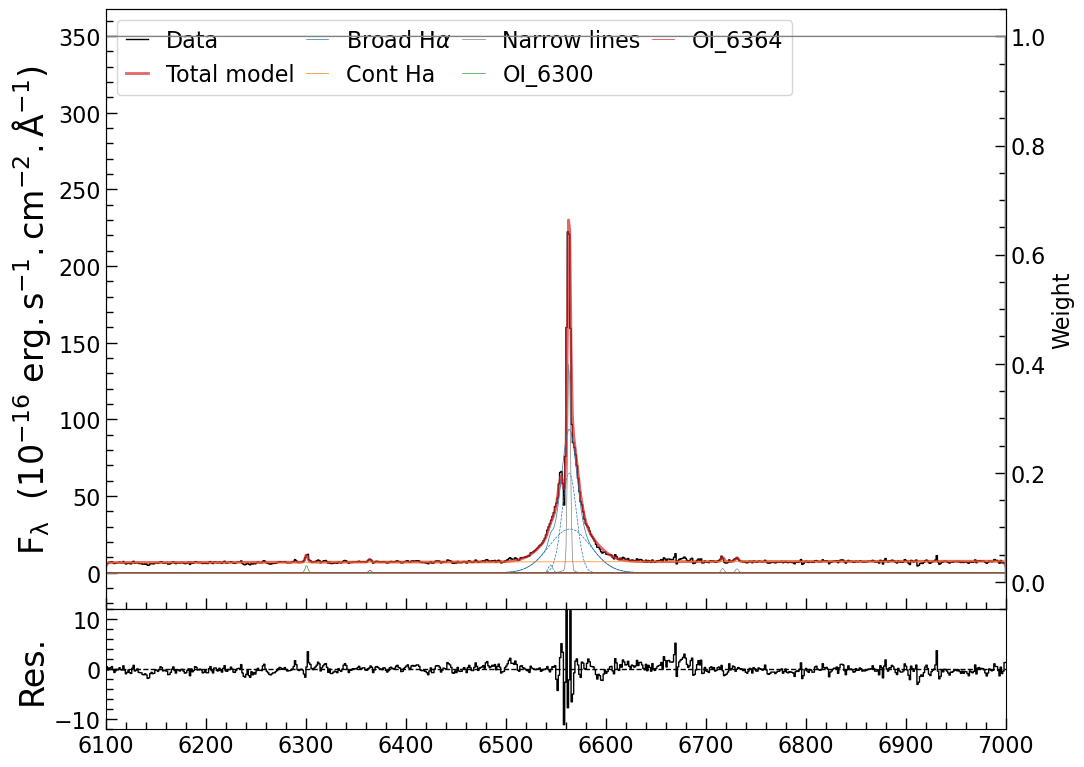

<Line_MultiGauss(amp_c=65.16396315, dv_c=27.44018694, sigma_c=328.98092903, wavec=6562.819, amp_w0=0.43680894, dv_w0=28.25367815, sigma_w0=950.39735447, amp_w1=0.07814017, dv_w1=-854.57908612, sigma_w1=99.4668523, name='Broad H$\\alpha$')>
<WindowedPowerLaw1D(amplitude=7.08030924, x_0=6550., alpha=-0.9154597, x_min=6100., x_max=7000., name='Cont Ha')>
<Line_Absorption(logtau0=1.46040926, dv=-176.88849014, sigma=30., Cf=0.5, wavec=6562.819, name='Abs. H$\\alpha$')>
<Line_template(amplitude=145.07267765, dv=19.21841329, wavec=6562.819, name='nHalpha')>
<Line_template(amplitude=2.86333094, dv=19.21841329, wavec=6716.44, name='SII_6716')>
<Line_template(amplitude=2.65925813, dv=19.21841329, wavec=6730.81, name='SII_6731')>
<Line_template(amplitude=0., dv=19.21841329, wavec=6583.46, name='NII_6583')>
<Line_template(amplitude=0., dv=19.21841329, wavec=6548.05, name='NII_6548')>
<Line_template(amplitude=4.92411956, dv=19.21841329, wavec=6300.304, name='OI_6300')>
<Line_template(amplitude=1.64

In [8]:
# Fit Halpha
window = line_windows[1]
weight_lines = np.zeros_like(wave_use)
weight_lines[(wave_use > window[0]) & (wave_use < window[1])] = 1

#cont_ha = models.PowerLaw1D(amplitude=9.66507821, x_0=6550., alpha=1.34015076, fixed=dict(x_0=True), name='Cont Ha')
cont_ha = galspec.WindowedPowerLaw1D(amplitude=7.40685884, x_0=6550., alpha=-0.12861649, x_min=window[0], x_max=window[1], name='Cont Ha')

bha = galspec.Line_MultiGauss(n_components=3, amp_c=62.95519077, dv_c=32.04076332, sigma_c=339.03512219, 
                            amp_w0=0.44492696, dv_w0=22.05468792, sigma_w0=959.01074013, 
                            amp_w1=0.06793915, dv_w1=-854.57908612, sigma_w1=126.66425228,
                            wavec=wave_dict['Halpha'], name=label_bHa)
bha.dv_w1.fixed = True
nha = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=158.76879449, dv=20.81267834,
                          wavec=wave_dict['Halpha'], name='nHalpha')
ns2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2, dv=20.81267834,
                          wavec=wave_dict['SII_6716'], name='SII_6716') +\
         galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2, dv=20.81267834,
                            wavec=wave_dict['SII_6731'], name='SII_6731')
nn2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=0, dv=0, 
                          wavec=wave_dict['NII_6583'], name='NII_6583', fixed=dict(amplitude=True, dv=True)) +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=0, dv=0, 
                         wavec=wave_dict['NII_6548'], name='NII_6548', fixed=dict(amplitude=True, dv=True))
no1 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=6.10893294, dv=-2.88104644,
                          wavec=wave_dict['OI_6300'], name='OI_6300') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2.03631131, dv=-2.88104644,
                          wavec=wave_dict['OI_6364'], name='OI_6364')

aha = galspec.Line_Absorption(logtau0=1.76156979, dv=-178.79943272, sigma=30.0, Cf=0.5, 
                            wavec=wave_dict['Halpha'], name=label_aHa)
aha.Cf.fixed = True
aha.sigma.fixed = True
aha.sigma.bounds = (5, 1000)

b_lines = (bha + cont_ha) * aha
b_lines = galspec.convolve_lsf(b_lines, wavec=bha.wavec, resolving_power=resolving_power)
n_lines = nha + ns2 + nn2 + no1
m_init = b_lines + n_lines
m_init['NII_6548'].amplitude.tied = galspec.tie_template_amplitude('NII_6583', ratio=2.96)
m_init['OI_6364'].amplitude.tied = galspec.tie_template_amplitude('OI_6300', ratio=3.0)

for ln in ['SII_6716', 'SII_6731', 'NII_6583', 'NII_6548', 'OI_6300', 'OI_6364']:  #
    m_init[ln].dv.tied = galspec.tie_template_dv('nHalpha')


fitter = fitting.LevMarLSQFitter()
m_fit_ha = fitter(m_init, wave_use, flux_use, weights=weight_lines, maxiter=10000)

ignore_list = [label_aHa]
legend_map = {('gray', 'Narrow lines'): ['nHalpha', 'NII_6583', 'NII_6548', 'SII_6716', 'SII_6731']}
ax, axr = galspec.plot.plot_fit(wave_use, flux_use, m_fit_ha, weight=weight_lines, 
                              legend_map=legend_map, ignore_list=ignore_list)
#ax, axr = galspec.plot.plot_fit(wave_use, flux_res, m_init, weight=weight_lines)
#ax.axvspan(xmin=6558, xmax=6566, alpha=0.5, color='C3')
ax.set_ylabel(r'$\rm {F_\lambda\ \ (10^{-16} \ erg.s^{-1}.cm^{-2}.{\AA}^{-1})}$', fontsize=24)
ax.set_xlim(window[0], window[1])
axr.set_ylim(-12, 12)
plt.show()

for m in m_fit_ha:
    print(m.__repr__())

### Fit Hɑ + (Hβ and Hγ)


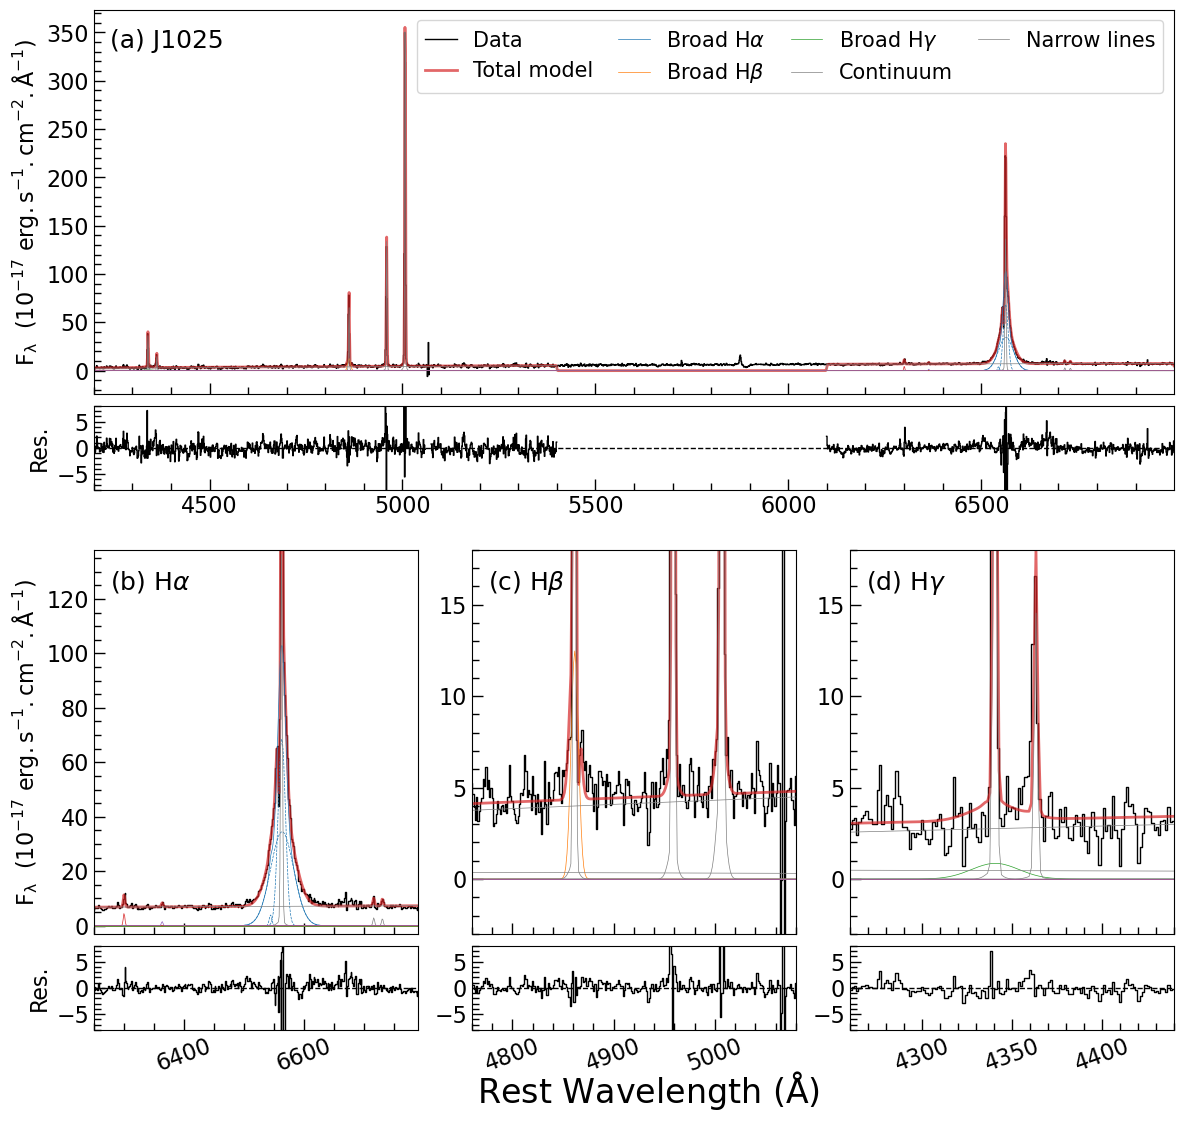

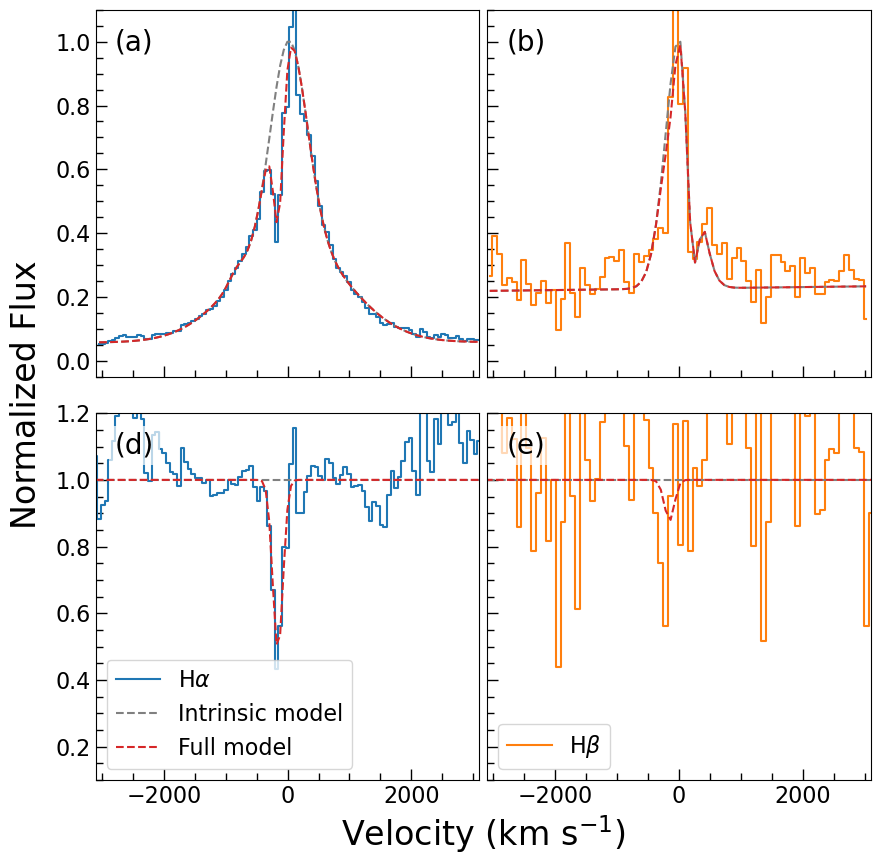

<Line_MultiGauss__GaussConv1D(amp_c=12.47376134, dv_c=23.48323244, sigma_c=226.39942223, wavec=4861.333, name='Broad H$\\beta$')>
<Line_MultiGauss__GaussConv1D(amp_c=0.85765066, dv_c=23.48323244, sigma_c=911.92382387, wavec=4340.471, name='Broad H$\\gamma$')>
<WindowedPowerLaw1D(amplitude=0.30796597, x_0=5100., alpha=2.48962469, x_min=4200., x_max=5400., name='PL')>
<BlackBody(temperature=3787.35400386, scale=7.19407202, x_min=4200., x_max=5400., name='BB')>
<Line_Absorption(logtau0=-0.52479119, dv=-158.08130049, sigma=36.83253957, Cf=1., wavec=4861.333, name='Abs. H$\\beta$')>
<Line_Absorption(logtau0=-0.99762761, dv=-158.08130049, sigma=36.83253957, Cf=1., wavec=4340.471, name='Abs. H$\\gamma$')>
<Line_Absorption(logtau0=1.27041433, dv=220.15939132, sigma=30., Cf=0.8, wavec=4861.333, name='Abs. H$\\beta$2')>
<IronTemplate(amplitude=0., stddev=1000., z=0., name='Fe II')>
<Line_template(amplitude=66.7998004, dv=8.83236704, wavec=4861.333, name='nHbeta')>
<Line_template(amplitude=37.233

In [ ]:
# Fit Halpha + Hbeta + Hgamma
weight_lines = np.zeros_like(wave_use)
xlim = [wave_use.max(), wave_use.min()]
for window in line_windows:
    weight_lines[(wave_use > window[0]) & (wave_use < window[1])] = 1
    xlim[0] = min(xlim[0], window[0])
    xlim[1] = max(xlim[1], window[1])
weight_lines[(wave_use > 5060) & (wave_use < 5075)] = 0  # Mask some back pixels

# Hbeta
pl = galspec.WindowedPowerLaw1D(amplitude=0.55023723, x_0=5100., alpha=2.48962469, x_min=line_windows[0][0], x_max=line_windows[0][1],
                              fixed={'x_0': True, 'alpha': True}, name='PL')
bb = galspec.BlackBody(temperature=3604.37589785, scale=7.19407202, x_min=line_windows[0][0], x_max=line_windows[0][1],
                     fixed={'scale': True}, name='BB')
cont = pl + bb
iron = galspec.IronTemplate(amplitude=0, stddev=1000.0, z=0, name='Fe II', fixed=dict(amplitude=True, z=True, stddev=True))

bhb = galspec.Line_MultiGauss(n_components=1, amp_c=5, dv_c=21.90721623, sigma_c=900,
                            #amp_w0=0.2, dv_w0=0, sigma_w0=963.65580399, 
                            #amp_w1=0.07300808, dv_w1=-878.26032089, sigma_w1=140.10792513,
                            wavec=wave_dict['Hbeta'], name=label_bHb)
bhb.sigma_c.bounds = (200, 1000)
nhb = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=86.43864336, dv=8.39263981, 
                          wavec=wave_dict['Hbeta'], name='nHbeta')
no3 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=405.93273529, dv=8.39263981, 
                          wavec=wave_dict['OIII_5007'], name='OIII_5007') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=136.21903869, dv=8.39263981, 
                         wavec=wave_dict['OIII_4959'], name='OIII_4959')
#no3_w = galspec.Line_MultiGauss_doublet(n_components=1, amp_c0=5, amp_c1=1.3, dv_c=-140, sigma_c=280, 
#                                      wavec0=wave_dict['OIII_5007'], wavec1=wave_dict['OIII_4959'], name='[OIII]w')
ahb = galspec.Line_Absorption(logtau0=0., dv=-106.29309827, sigma=30., Cf=0.5, wavec=wave_dict['Hbeta'], name=label_aHb)
#ahb.Cf.fixed = True
#ahb.sigma.fixed = True
ahb.sigma.bounds = (5, 1000)
ahb2 = galspec.Line_Absorption(logtau0=0.47576711, dv=218.3479254, sigma=30., Cf=0.8, wavec=wave_dict['Hbeta'], name=label_aHb+'2')
ahb2.Cf.fixed = True
ahb2.sigma.fixed = True
ahb2.sigma.bounds = (5, 1000)

# Hgamma
bhg = galspec.Line_MultiGauss(n_components=1, amp_c=0.5, dv_c=47.43140249, sigma_c=637.5607882,
                            #amp_w0=0.14521271, dv_w0=-20.76443383, sigma_w0=1428.23875816, 
                            #amp_w1=0.14233795, dv_w1=956.81234491, sigma_w1=262.7280666,
                            wavec=wave_dict['Hgamma'], name=label_bHg)
nhg = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=40, dv=0, 
                          wavec=wave_dict['Hgamma'], name='nHgamma')
no3_4363 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=20, dv=0, 
                               wavec=wave_dict['OIII_4363'], name='OIII_4363')
#no3_4363_w = galspec.Line_MultiGauss(n_components=2, amp_c=5, dv_c=-102.72494161, sigma_c=138.17275064, 
#                                   amp_w0=0.51564118, dv_w0=-57.20856779, sigma_w0=300.65959177,
#                                   wavec=wave_dict['OIII_4363'], name='OIII_4363_w')
ahg = galspec.Line_Absorption(logtau0=-0.6, dv=64.5, sigma=70., Cf=0.5, wavec=wave_dict['Hgamma'], name=label_aHg)
#ahg.Cf.fixed = True
#ahg.sigma.fixed = True
ahg.sigma.bounds = (5, 1000)


#m_init = (bhb + cont_hb + nhb) * ahb * ahb2 + no3 + deepcopy(m_fit_ha)
b_lines = (bhb + bhg + cont) * ahb * ahg * ahb2  #
b_lines = galspec.convolve_lsf(b_lines, wavec=bhb.wavec, resolving_power=resolving_power)
m_init = b_lines + iron + nhb + nhg + no3 + no3_4363 + deepcopy(m_fit_ha)  # + no3_w

for ln in ['nHbeta', 'OIII_5007', 'OIII_4959', 'nHgamma', 'OIII_4363']:
    m_init[ln].dv.tied = galspec.tie_template_dv('nHalpha')

m_init['OIII_4959'].amplitude.tied = galspec.tie_template_amplitude('OIII_5007', 2.98)
#m_init['[OIII]w'].amp_c1.tied = galspec.tie_MultiGauss_doublet_ratio('[OIII]w', ratio=2.98)

m_init[label_aHb].logtau0.tied = galspec.tie_Absorption_logtau0(label_aHa, ratio=7.13)
m_init[label_aHg].logtau0.tied = galspec.tie_Absorption_logtau0(label_aHa, ratio=21.18)
m_init[label_aHa].logtau0 = 1
m_init[label_aHb].dv.tied = galspec.tie_Absorption_dv(label_aHa)
m_init[label_aHg].dv.tied = galspec.tie_Absorption_dv(label_aHa)
m_init[label_aHa].Cf.fixed = False
m_init[label_aHb].Cf.tied = galspec.tie_Absorption_Cf(label_aHa)
m_init[label_aHg].Cf.tied = galspec.tie_Absorption_Cf(label_aHa)
m_init[label_aHb].sigma.tied = galspec.tie_Absorption_sigma(label_aHa)
m_init[label_aHg].sigma.tied = galspec.tie_Absorption_sigma(label_aHa)
m_init[label_aHa].sigma.fixed = False

m_init[label_bHb].dv_c.tied = galspec.tie_MultiGauss_dv_c(label_bHa)
#m_init['bHbeta'].dv_w0.tied = galspec.tie_MultiGauss_dv_w0('bHalpha')
#m_init['bHbeta'].dv_w1.tied = galspec.tie_MultiGauss_dv_w1('bHalpha')

m_init[label_bHg].dv_c.tied = galspec.tie_MultiGauss_dv_c(label_bHa)


fitter = fitting.LevMarLSQFitter()
m_fit_hb = fitter(m_init, wave_use, flux_use, weights=weight_lines, maxiter=10000)

tu.plot_all_4p_J1025(wave_use, flux_use, m_fit_hb, weight=weight_lines)
#tu.plot_all_4p_J1025(wave_use, flux_use, m_init, weight=weight_lines)
#plt.savefig('figs/J1025+1402_4p.pdf', bbox_inches='tight')
plt.show()

cont_models = ['PL', 'BB', 'Cont Ha']
balmer_em_models = [label_bHa, label_bHb, label_bHg]
balmer_abs_models = [[label_aHa], [label_aHb], [label_aHg]]
line_names = ['Halpha', 'Hbeta']
tu.plot_decomposed_balmer(wave_use, flux_use, m_fit_hb, cont_models, balmer_abs_models, 
                          balmer_em_models, line_names, xlim=(-3100, 3100), ylim2=[0.1, 1.2])
#plt.savefig('figs/J1025+1402_balmer.pdf', bbox_inches='tight')
plt.show()   

for m in m_fit_hb:
    print(m.__repr__())

### Run MCMC fitting

In [ ]:
mcmc1 = tu.run_mcmc_balmer(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, 
                           nwalkers=200, nsteps=15000, step_initial=5000, fit=True)
mcmc1.check_convergence()
mcmc1.save_samples('results/samples/J1025+1402_samples_balmer.npz')
galspec.save_mcmc(mcmc1, 'results/models/galspec-model-J1025+1402.pkl')
    
mcmc2 = tu.run_mcmc_others(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, 
                           nwalkers=200, nsteps=15000, step_initial=5000, fit=True)
mcmc2.check_convergence()
mcmc2.save_samples('results/samples/J1025+1402_samples_others.npz')

1640 points used in MCMC for broad lines.
MCMC_Fit initialized with 31 free parameters.


  0%|          | 0/5000 [00:00<?, ?it/s]/Users/shangguan/Softwares/miniforge3/envs/norm/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 15000/15000 [2:54:28<00:00,  1.43it/s]     


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 31 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 300;
tau: [1024.53120651  996.50190214 1363.55347923 1237.3694782   817.40423246
  818.39580904  930.3524199   896.11229159  955.6196583  1156.035559
  796.52034229  830.40047336  820.14306243  933.62270071  807.23791149
  793.37715994  857.36913279  799.99556201  812.94400215  928.57817656
  838.47832044  776.13616665 1012.70779009  914.10168058 1001.46565343
  807.91391538  849.09486021  811.17556924  735.58787562  841.71556314
  778.75773861]
Chain is probably too short to reliably estimate tau.
MCMC_Fit initialized with 13 free parameters.


100%|██████████| 15000/15000 [49:48<00:00,  5.02it/s]   


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 1 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 300;
tau: [252.98779741 251.54822612 333.1659847  283.89706177 279.2892478
 283.29685838 269.21522495 245.89724266 258.64064346 248.08340575
 253.9892458  281.64004893 251.6306692 ]
Chain is probably too short to reliably estimate tau.


### Load the MCMC fitting
* Save the best-fit model figure
* Save the decomposed absorption line figure

1640 points used in MCMC for broad lines.
MCMC_Fit initialized with 31 free parameters.
MCMC_Fit initialized with 13 free parameters.


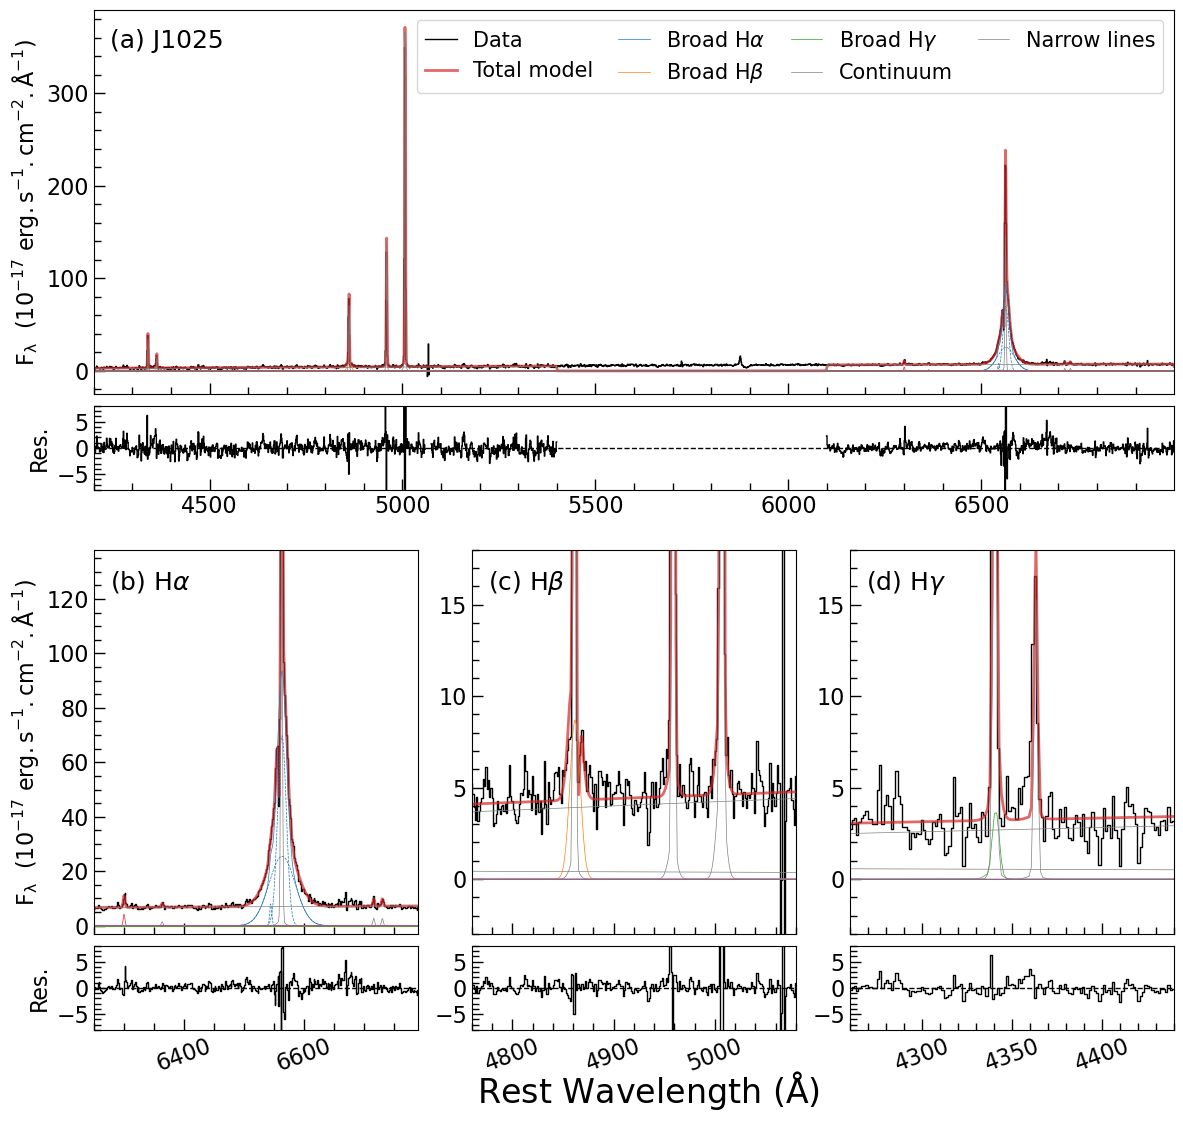

/Users/shangguan/Dropbox/Products/Latex/Absorption_selection/work/fitting_nb/temp_utils.py:390: RuntimeWarning: divide by zero encountered in divide
  m_conv_list = sagan.find_convolved_submodels(m_fit)
/Users/shangguan/Dropbox/Products/Latex/Absorption_selection/work/fitting_nb/temp_utils.py:390: RuntimeWarning: overflow encountered in divide
  m_conv_list = sagan.find_convolved_submodels(m_fit)


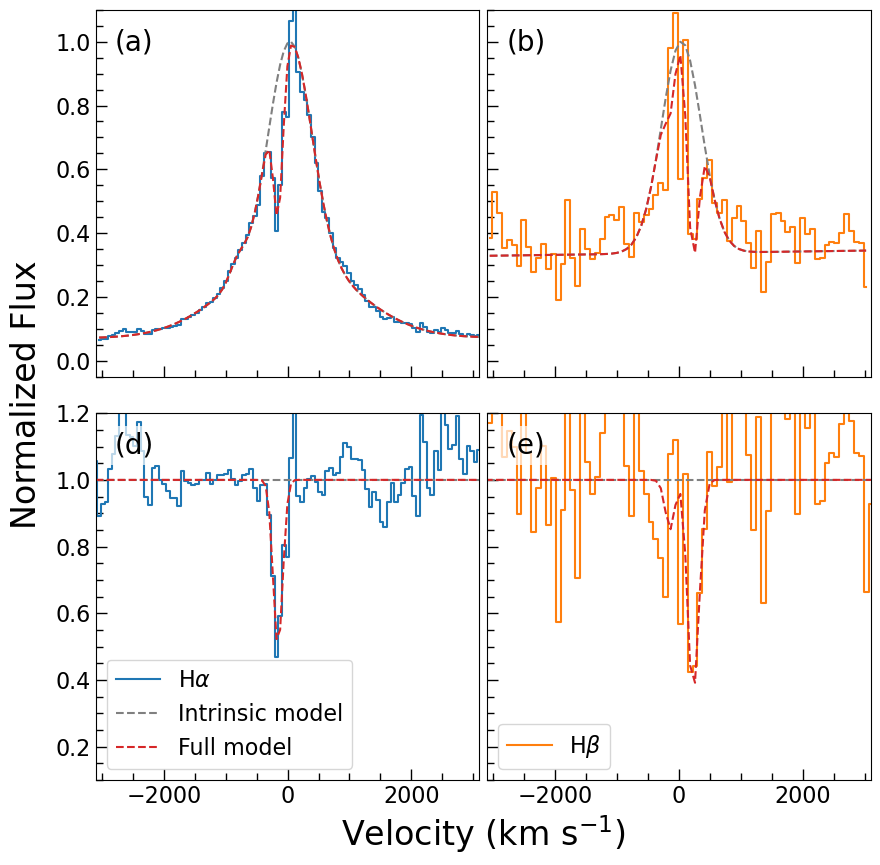

<Line_MultiGauss__GaussConv1D(amp_c=8.94020615, dv_c=39.63645723, sigma_c=306.56033484, wavec=4861.333, name='Broad H$\\beta$')>
<Line_MultiGauss__GaussConv1D(amp_c=4.70582541, dv_c=39.63645723, sigma_c=108.70466183, wavec=4340.471, name='Broad H$\\gamma$')>
<WindowedPowerLaw1D(amplitude=0.35809685, x_0=5100., alpha=2.48962469, x_min=4200., x_max=5400., name='PL')>
<BlackBody(temperature=3759.13352111, scale=7.19407202, x_min=4200., x_max=5400., name='BB')>
<Line_Absorption(logtau0=-0.20052685, dv=-160.59420988, sigma=24.93424099, Cf=0.96366934, wavec=4861.333, name='Abs. H$\\beta$')>
<Line_Absorption(logtau0=-0.67336327, dv=-160.59420988, sigma=24.93424099, Cf=0.96366934, wavec=4340.471, name='Abs. H$\\gamma$')>
<Line_Absorption(logtau0=1.86078275, dv=241.73142242, sigma=30., Cf=0.8, wavec=4861.333, name='Abs. H$\\beta$2')>
<IronTemplate(amplitude=0., stddev=1000., z=0., name='Fe II')>
<Line_template(amplitude=72.71465879, dv=8.11846308, wavec=4861.333, name='nHbeta')>
<Line_template(

In [10]:
mcmc1 = tu.run_mcmc_balmer(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, fit=False)
mcmc2 = tu.run_mcmc_others(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, fit=False)

mcmc1.load_samples('results/samples/J1025+1402_samples_balmer.npz')
mcmc2.load_samples('results/samples/J1025+1402_samples_others.npz')

m_fit1, _, _ = mcmc1.get_best_fit()
m_fit2, _, _ = mcmc2.get_best_fit()

tu.plot_all_4p_J1025(wave_use, flux_use, m_fit1, weight=weight_lines)
plt.savefig('figs/J1025+1402_4p.pdf', bbox_inches='tight')
plt.show()

cont_models = ['PL', 'BB', 'Cont Ha']
balmer_em_models = [label_bHa, label_bHb, label_bHg]
balmer_abs_models = [[label_aHa], [label_aHb, label_aHb+'2'], [label_aHg]]
line_names = ['Halpha', 'Hbeta']

tu.plot_decomposed_balmer(wave_use, flux_use, m_fit1, cont_models, balmer_abs_models, 
                          balmer_em_models, line_names, xlim=(-3100, 3100), ylim2=[0.1, 1.2])
plt.savefig('figs/J1025+1402_balmer.pdf', bbox_inches='tight')
plt.show()   

#tu.plot_all_4p_J1025(wave_use, flux_use, m_fit2, weight=weight_lines)
#plt.show()

for m in m_fit1:
    print(m.__repr__())

In [9]:
res = tu.measure_phys(mcmc1, mcmc2, wave_use, zred, nsamples=500, cont_names=['PL', 'BB', 'Cont Ha'])
tb = tu.table_phys(res)
tb.write('results/J1025+1402_phys_table.ipac', format='ipac', overwrite=True)
tb.show_in_notebook()

         interactive tables it is recommended to use dedicated tools like:
         - https://github.com/bloomberg/ipydatagrid
         - https://docs.bokeh.org/en/latest/docs/user_guide/interaction/widgets.html#datatable
         - https://dash.plotly.com/datatable [warnings]


idx,Parameter,Value,Error
0,Flux_broad_Ha,2688.693647935892,14.187189212896719
1,Flux_narrow_Ha,548.6822969036814,9.965830195977732
2,FWHM_broad_Ha,936.1907483037335,24.158834888333217
3,EW_abs_Ha,2.0984657034677805,0.06282173025170518
4,Cf_abs_Ha,0.9529164298684643,0.044498514442287126
5,logtau0_abs_Ha,0.6158325184439896,0.1679001295215155
6,dv_abs_Ha,-158.01703518670723,3.93940184155467
7,sigma_abs_Ha,25.79929037617181,4.216468273331792
8,EW_em_Ha,382.248860839656,2.5475442635031125
9,Flux_broad_Hb,102.1027554966121,8.90333024428276


MCMC_Fit initialized with 31 free parameters.
